In [28]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import SimpleITK as sitk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import List, Tuple, Dict, Optional, Any
import warnings
from sklearn.model_selection import train_test_split
from torch.cuda.amp import autocast, GradScaler
import time
from collections import defaultdict
import logging
import copy
from matplotlib.colors import ListedColormap, BoundaryNorm

In [7]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

### DATASET

In [8]:
class MultiAnnotatorProstateDataset(Dataset):
    """
    Dataset for loading prostate MRI data with simulated multi-annotator support.
    In real scenario, this would load annotations from different doctors.
    """
    
    def __init__(self, 
                 data_root: str, 
                 labels_root: str,
                 patient_ids: List[str],
                 modalities: List[str] = ['cor', 'sag', 't2w'],
                 transform=None,
                 target_size: Tuple[int, int] = (256, 256),
                 normalize: bool = True,
                 num_annotators: int = 3,
                 annotator_variance: float = 0.1):
        """
        Args:
            data_root: Root directory containing patient data folders
            labels_root: Root directory containing anatomical labels
            patient_ids: List of patient IDs to include
            modalities: List of modalities to load
            transform: Optional transform to apply
            target_size: Target size for resizing (height, width)
            normalize: Whether to normalize images to [0, 1]
            num_annotators: Number of simulated annotators
            annotator_variance: Amount of noise to add to simulate different annotators
        """
        self.data_root = data_root
        self.labels_root = labels_root
        self.patient_ids = patient_ids
        self.modalities = modalities
        self.transform = transform
        self.target_size = target_size
        self.normalize = normalize
        self.num_annotators = num_annotators
        self.annotator_variance = annotator_variance
        
        # Store file paths
        self.samples = []
        
        for pid in patient_ids:
            # Construct file paths
            patient_path = os.path.join(data_root, pid)
            label_path = os.path.join(labels_root, pid)
            
            if not os.path.exists(patient_path) or not os.path.exists(label_path):
                logger.warning(f"Missing data for patient {pid}")
                continue
            
            # Get all available modalities
            available_files = os.listdir(patient_path)
            
            # Check if required modalities exist
            modality_files = {}
            for modality in modalities:
                # Try with and without leading zeros
                pattern_variants = [
                    f"{pid.lstrip('0')}_{modality}.mha",
                    f"{int(pid)}_{modality}.mha",
                    f"{pid}_{modality}.mha"
                ]
                
                for pattern in pattern_variants:
                    matching_files = [f for f in available_files if f == pattern]
                    if matching_files:
                        modality_files[modality] = os.path.join(patient_path, matching_files[0])
                        break
                
                if modality not in modality_files:
                    logger.warning(f"Missing {modality} for patient {pid}")
            
            if len(modality_files) == len(modalities):
                # Get anatomical labels
                label_files = {}
                available_labels = os.listdir(label_path)
                anatomical_regions = ['afs', 'cz', 'pg', 'pz', 'sv_l', 'sv_r', 'tz']
                
                for region in anatomical_regions:
                    # Try with and without leading zeros
                    pattern_variants = [
                        f"{pid.lstrip('0')}_{region}_t2w.nii.gz",
                        f"{int(pid)}_{region}_t2w.nii.gz",
                        f"{pid}_{region}_t2w.nii.gz"
                    ]
                    
                    for pattern in pattern_variants:
                        matching_files = [f for f in available_labels if pattern in f]
                        if matching_files:
                            label_files[region] = os.path.join(label_path, matching_files[0])
                            break
                
                self.samples.append({
                    'patient_id': pid,
                    'modality_files': modality_files,
                    'label_files': label_files
                })
        
        logger.info(f"Loaded {len(self.samples)} patients with {len(modalities)} modalities each")
        logger.info(f"Simulating {num_annotators} annotators with variance {annotator_variance}")
    
    def __len__(self):
        return len(self.samples)
    
    def load_image(self, filepath: str) -> np.ndarray:
        """Load medical image using SimpleITK"""
        try:
            if filepath.endswith('.mha') or filepath.endswith('.nii.gz'):
                image = sitk.ReadImage(filepath)
                array = sitk.GetArrayFromImage(image)
                
                # Handle 3D volumes - take middle slice
                if len(array.shape) == 3:
                    # For MRI, typically shape is (slices, height, width)
                    middle_slice = array.shape[0] // 2
                    array = array[middle_slice]
                
                # Resize if needed
                if self.target_size and array.shape != self.target_size:
                    from scipy.ndimage import zoom
                    zoom_factors = (
                        self.target_size[0] / array.shape[0],
                        self.target_size[1] / array.shape[1]
                    )
                    array = zoom(array, zoom_factors, order=1)  # Linear interpolation
                
                # Normalize to [0, 1]
                if self.normalize:
                    array_min = array.min()
                    array_max = array.max()
                    if array_max > array_min:
                        array = (array - array_min) / (array_max - array_min)
                    else:
                        array = np.zeros_like(array)
                
                return array
            else:
                raise ValueError(f"Unsupported file format: {filepath}")
        except Exception as e:
            logger.error(f"Error loading {filepath}: {e}")
            return np.zeros(self.target_size)
    
    def load_labels(self, label_files: Dict) -> Dict[str, np.ndarray]:
        """Load all anatomical labels"""
        labels = {}
        for region, filepath in label_files.items():
            try:
                label = sitk.ReadImage(filepath)
                array = sitk.GetArrayFromImage(label)
                
                # Handle 3D volumes - take middle slice
                if len(array.shape) == 3:
                    middle_slice = array.shape[0] // 2
                    array = array[middle_slice]
                
                # Binarize (some labels might have different values)
                array = (array > 0).astype(np.float32)
                
                # Resize if needed
                if self.target_size and array.shape != self.target_size:
                    from scipy.ndimage import zoom
                    zoom_factors = (
                        self.target_size[0] / array.shape[0],
                        self.target_size[1] / array.shape[1]
                    )
                    array = zoom(array, zoom_factors, order=0)  # Nearest neighbor for masks
                
                labels[region] = array
            except Exception as e:
                logger.error(f"Error loading label {region}: {e}")
                labels[region] = np.zeros(self.target_size)
        
        return labels
    
    def add_annotator_noise(self, label_tensor: torch.Tensor, annotator_id: int) -> torch.Tensor:
        """
        Add simulated noise to annotations to represent different annotators.
        In real scenario, this would be actual annotations from different doctors.
        """
        if annotator_id == 0:
            # Annotator 0: Original (most reliable)
            return label_tensor.clone()
        else:
            # Add increasing noise for other annotators
            noisy_labels = label_tensor.clone()
            noise_level = self.annotator_variance * annotator_id
            
            # Randomly flip some pixels
            flip_mask = torch.rand_like(noisy_labels) < noise_level
            # For simplicity, we just zero out some pixels
            # In real scenario, you might have more complex noise patterns
            noisy_labels[flip_mask] = 0
            
            return noisy_labels
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Load all modalities
        modality_images = []
        for modality in self.modalities:
            if modality in sample['modality_files']:
                img = self.load_image(sample['modality_files'][modality])
                modality_images.append(img)
            else:
                # Fill with zeros if modality missing
                modality_images.append(np.zeros(self.target_size))
        
        # Stack modalities along channel dimension
        image = np.stack(modality_images, axis=0).astype(np.float32)
        
        # Load labels
        labels_dict = self.load_labels(sample['label_files'])
        
        # Convert labels dict to tensor
        base_labels = np.stack([
            labels_dict.get('afs', np.zeros(self.target_size)),
            labels_dict.get('cz', np.zeros(self.target_size)),
            labels_dict.get('pg', np.zeros(self.target_size)),
            labels_dict.get('pz', np.zeros(self.target_size)),
            labels_dict.get('sv_l', np.zeros(self.target_size)),
            labels_dict.get('sv_r', np.zeros(self.target_size)),
            labels_dict.get('tz', np.zeros(self.target_size))
        ], axis=0).astype(np.float32)
        
        # Apply transformations
        if self.transform:
            image = self.transform(image)
            base_labels = self.transform(base_labels)
        
        # Convert to PyTorch tensors
        image_tensor = torch.from_numpy(image)
        base_labels_tensor = torch.from_numpy(base_labels)
        
        # Generate annotations from multiple annotators
        annotator_labels = []
        for i in range(self.num_annotators):
            noisy_labels = self.add_annotator_noise(base_labels_tensor, i)
            annotator_labels.append(noisy_labels)
        
        # Stack annotator labels
        all_labels = torch.stack(annotator_labels, dim=0)  # [num_annotators, num_classes, H, W]
        
        return {
            'image': image_tensor,
            'labels': all_labels,  # Multiple annotator labels
            'base_label': base_labels_tensor,  # Clean/original label
            'patient_id': sample['patient_id'],
            'label_names': ['AFS', 'CZ', 'PG', 'PZ', 'SV_L', 'SV_R', 'TZ'],
            'num_annotators': self.num_annotators
        }

### FUSION

In [9]:
class MultiAnnotatorFusion:
    """
    Implements our multi-annotator fusion approach.
    Handles pixel-level ambiguity, annotator reliability, and probabilistic fusion.
    """
    
    def __init__(self, num_classes: int = 7, epsilon: float = 1e-8):
        self.num_classes = num_classes
        self.epsilon = epsilon
        self.annotator_reliabilities = None
        
    def compute_pixel_ambiguity(self, annotations: torch.Tensor) -> torch.Tensor:
        """
        Compute pixel-level ambiguity weights.
        
        Args:
            annotations: Tensor of shape [N, H, W] where N is number of annotators
                        Each pixel contains class index (0-6)
        
        Returns:
            ambiguity_weights: Tensor of shape [H, W] with values in [0, 1]
        """
        N, H, W = annotations.shape
        
        # Compute class distribution for each pixel
        pixel_ambiguity = torch.zeros(H, W, device=annotations.device)
        
        for i in range(H):
            for j in range(W):
                pixel_votes = annotations[:, i, j]
                # Count votes for each class
                class_counts = torch.zeros(self.num_classes, device=annotations.device)
                for c in range(self.num_classes):
                    class_counts[c] = (pixel_votes == c).sum().float()
                
                # Probability distribution
                p = class_counts / N
                # Ambiguity weight: 1 - max probability
                pixel_ambiguity[i, j] = 1 - p.max()
        
        return pixel_ambiguity
    
    def compute_annotator_reliability(self, annotations: torch.Tensor) -> torch.Tensor:
        """
        Compute weighted annotator reliability scores.
        
        Args:
            annotations: Tensor of shape [N, H, W] where N is number of annotators
        
        Returns:
            reliability_scores: Tensor of shape [N] with reliability scores
        """
        N, H, W = annotations.shape
        
        # Compute pixel ambiguity weights
        ambiguity_weights = self.compute_pixel_ambiguity(annotations)
        
        # Compute reliability for each annotator
        reliability_scores = torch.zeros(N, device=annotations.device)
        
        for i in range(N):
            total_weighted_agreement = 0
            total_agreement_pairs = 0
            
            for j in range(N):
                if i != j:
                    # Compute agreement between annotator i and j
                    agreement_mask = (annotations[i] == annotations[j]).float()
                    
                    # Weighted agreement
                    weighted_agreement = (ambiguity_weights * agreement_mask).sum()
                    total_weight = ambiguity_weights.sum()
                    
                    if total_weight > self.epsilon:
                        total_weighted_agreement += weighted_agreement / total_weight
                        total_agreement_pairs += 1
            
            if total_agreement_pairs > 0:
                reliability_scores[i] = total_weighted_agreement / total_agreement_pairs
        
        self.annotator_reliabilities = reliability_scores
        return reliability_scores
    
    def probabilistic_fusion(self, annotations: torch.Tensor, 
                           reliabilities: torch.Tensor = None) -> torch.Tensor:
        """
        Fuse multiple annotations into probabilistic label maps.
        
        Args:
            annotations: Tensor of shape [N, H, W] with class indices
            reliabilities: Optional reliability scores (if None, compute them)
        
        Returns:
            fused_probabilities: Tensor of shape [num_classes, H, W] with probabilities
        """
        N, H, W = annotations.shape
        
        if reliabilities is None:
            reliabilities = self.compute_annotator_reliability(annotations)
        
        # Initialize probability map
        fused_probabilities = torch.zeros(self.num_classes, H, W, 
                                         device=annotations.device)
        
        # Normalize reliabilities
        if reliabilities.sum() > self.epsilon:
            normalized_reliabilities = reliabilities / reliabilities.sum()
        else:
            normalized_reliabilities = torch.ones_like(reliabilities) / N
        
        # Aggregate votes weighted by reliability
        for i in range(N):
            annotator_mask = annotations[i]
            reliability_weight = normalized_reliabilities[i]
            
            for c in range(self.num_classes):
                class_mask = (annotator_mask == c).float()
                fused_probabilities[c] += reliability_weight * class_mask
        
        return fused_probabilities
    
    def get_hard_labels(self, probabilities: torch.Tensor) -> torch.Tensor:
        """Convert probabilities to hard labels (argmax)"""
        return torch.argmax(probabilities, dim=0)


class MultiAnnotatorUNetDataset(Dataset):
    """
    Dataset wrapper that applies multi-annotator fusion for training.
    """
    
    def __init__(self, base_dataset: MultiAnnotatorProstateDataset, 
                 fusion_method: MultiAnnotatorFusion = None,
                 use_probabilistic_labels: bool = True):
        self.base_dataset = base_dataset
        self.fusion_method = fusion_method or MultiAnnotatorFusion()
        self.use_probabilistic_labels = use_probabilistic_labels
        
    def __len__(self):
        return len(self.base_dataset)
    
    def __getitem__(self, idx):
        # Get multi-annotator data
        sample = self.base_dataset[idx]
        
        # Convert one-hot labels to class indices for fusion
        # Shape: [num_annotators, num_classes, H, W] -> [num_annotators, H, W]
        annotations = sample['labels']  # [N, C, H, W]
        N, C, H, W = annotations.shape
        
        # Convert to class indices
        annotations_idx = torch.argmax(annotations, dim=1)  # [N, H, W]
        
        # Apply fusion
        fused_probabilities = self.fusion_method.probabilistic_fusion(annotations_idx)
        
        if self.use_probabilistic_labels:
            # Use soft probabilistic labels
            labels = fused_probabilities
        else:
            # Use hard labels
            labels = self.fusion_method.get_hard_labels(fused_probabilities)
            # Convert back to one-hot
            labels = F.one_hot(labels.long(), num_classes=C).permute(2, 0, 1).float()
        
        return {
            'image': sample['image'],
            'labels': labels,
            'patient_id': sample['patient_id'],
            'original_labels': sample['labels'],  # Keep original for analysis
            'reliabilities': self.fusion_method.annotator_reliabilities,
            'label_names': sample['label_names']
        }

### U-NET MODEL

In [10]:
class DoubleConv(nn.Module):
    """Double convolution block"""
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    """U-Net architecture for prostate segmentation"""
    def __init__(self, n_channels=3, n_classes=7, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear
        
        # Encoder
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        
        # Decoder
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        
        # Output
        self.outc = OutConv(64, n_classes)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.constant_(module.weight, 1)
            nn.init.constant_(module.bias, 0)
    
    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        # Decoder with skip connections
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        # Output
        logits = self.outc(x)
        
        # Apply softmax for probabilistic output
        if self.training:
            # Return logits for loss computation
            return logits
        else:
            # Return probabilities for inference
            return F.softmax(logits, dim=1)

### DICE LOSS FUNCTION

In [11]:
class DiceLoss(nn.Module):
    """Dice Loss for segmentation"""
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        # pred: [B, C, H, W] probabilities
        # target: [B, C, H, W] one-hot encoded
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    """Combination of Dice and CrossEntropy losses"""
    def __init__(self, dice_weight=0.5, ce_weight=0.5):
        super(CombinedLoss, self).__init__()
        self.dice_loss = DiceLoss()
        self.ce_loss = nn.CrossEntropyLoss()
        self.dice_weight = dice_weight
        self.ce_weight = ce_weight
    
    def forward(self, pred, target):
        if target.dim() == 4:  # One-hot encoded
            # Convert to class indices for CE loss
            target_ce = torch.argmax(target, dim=1)
        else:
            target_ce = target
        
        dice = self.dice_loss(F.softmax(pred, dim=1), target)
        ce = self.ce_loss(pred, target_ce)
        
        return self.dice_weight * dice + self.ce_weight * ce

### TRAINER (TRAINING + EVALUATION)

In [29]:
class ProstateSegmentationTrainer:
    """Complete training and evaluation pipeline"""
    
    def __init__(self, 
                 model: nn.Module,
                 train_loader: DataLoader,
                 val_loader: DataLoader,
                 test_loader: DataLoader,
                 device: str = 'cuda' if torch.cuda.is_available() else 'cpu',
                 learning_rate: float = 1e-4,
                 weight_decay: float = 1e-5):
        
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.device = device
        
        # Loss function - use combined loss
        self.criterion = CombinedLoss(dice_weight=0.7, ce_weight=0.3)
        
        # Optimizer
        self.optimizer = torch.optim.AdamW(
            model.parameters(), 
            lr=learning_rate, 
            weight_decay=weight_decay
        )
        
        # Learning rate scheduler
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=5
        )
        
        # Gradient scaler for mixed precision
        self.scaler = GradScaler() if device == 'cuda' else None
        
        # Metrics tracking
        self.train_losses = []
        self.val_losses = []
        self.train_dice_scores = []
        self.val_dice_scores = []
        self.learning_rates = []
        
        # Best model tracking
        self.best_model_state = None
        self.best_val_loss = float('inf')
        self.best_val_dice = 0.0
        
        logger.info(f"Initialized trainer on device: {device}")
        logger.info(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    def train_epoch(self) -> Tuple[float, float]:
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        total_dice = 0
        num_batches = 0
        
        for batch_idx, batch in enumerate(self.train_loader):
            # Move data to device
            images = batch['image'].to(self.device)
            labels = batch['labels'].to(self.device)
            
            # Forward pass with mixed precision
            self.optimizer.zero_grad()
            
            if self.scaler:
                with autocast():
                    outputs = self.model(images)
                    loss = self.criterion(outputs, labels)
                
                # Backward pass with gradient scaling
                self.scaler.scale(loss).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
            
            # Compute dice score
            with torch.no_grad():
                probs = F.softmax(outputs, dim=1)
                dice_score = self.compute_dice_score(probs, labels)
            
            total_loss += loss.item()
            total_dice += dice_score
            num_batches += 1
            
            # Log progress
            if (batch_idx + 1) % 10 == 0:
                logger.info(f"  Batch {batch_idx+1}/{len(self.train_loader)}: "
                           f"Loss={loss.item():.4f}, Dice={dice_score:.4f}")
        
        avg_loss = total_loss / num_batches
        avg_dice = total_dice / num_batches
        
        return avg_loss, avg_dice
    
    def validate(self) -> Tuple[float, float, Dict]:
        """Validate model performance"""
        self.model.eval()
        total_loss = 0
        total_dice = 0
        num_batches = 0
        
        # Store per-class metrics
        class_dice_scores = defaultdict(list)
        
        with torch.no_grad():
            for batch in self.val_loader:
                images = batch['image'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                # Forward pass
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                
                # Compute probabilities
                probs = F.softmax(outputs, dim=1)
                
                # Compute overall dice
                dice_score = self.compute_dice_score(probs, labels)
                
                # Compute per-class dice
                batch_class_dice = self.compute_per_class_dice(probs, labels)
                for class_idx, dice in enumerate(batch_class_dice):
                    class_dice_scores[class_idx].append(dice)
                
                total_loss += loss.item()
                total_dice += dice_score
                num_batches += 1
        
        avg_loss = total_loss / num_batches
        avg_dice = total_dice / num_batches
        
        # Compute average per-class dice
        avg_class_dice = {}
        for class_idx, scores in class_dice_scores.items():
            avg_class_dice[class_idx] = np.mean(scores)
        
        return avg_loss, avg_dice, avg_class_dice
    
    def compute_dice_score(self, pred_probs: torch.Tensor, 
                          target: torch.Tensor, 
                          smooth: float = 1e-6) -> float:
        """Compute Dice similarity coefficient"""
        # Convert to hard predictions
        pred_classes = torch.argmax(pred_probs, dim=1)
        
        # Convert target to class indices if one-hot
        if target.dim() == 4:
            target_classes = torch.argmax(target, dim=1)
        else:
            target_classes = target
        
        # Compute dice per class and average
        num_classes = pred_probs.shape[1]
        dice_scores = []
        
        for class_idx in range(num_classes):
            pred_mask = (pred_classes == class_idx).float()
            target_mask = (target_classes == class_idx).float()
            
            intersection = (pred_mask * target_mask).sum()
            union = pred_mask.sum() + target_mask.sum()
            
            if union > 0:
                dice = (2. * intersection + smooth) / (union + smooth)
                dice_scores.append(dice.item())
        
        return np.mean(dice_scores) if dice_scores else 0.0
    
    def compute_per_class_dice(self, pred_probs: torch.Tensor, 
                              target: torch.Tensor,
                              smooth: float = 1e-6) -> List[float]:
        """Compute Dice score for each class"""
        pred_classes = torch.argmax(pred_probs, dim=1)
        
        if target.dim() == 4:
            target_classes = torch.argmax(target, dim=1)
        else:
            target_classes = target
        
        num_classes = pred_probs.shape[1]
        dice_scores = []
        
        for class_idx in range(num_classes):
            pred_mask = (pred_classes == class_idx).float()
            target_mask = (target_classes == class_idx).float()
            
            intersection = (pred_mask * target_mask).sum()
            union = pred_mask.sum() + target_mask.sum()
            
            if union > 0:
                dice = (2. * intersection + smooth) / (union + smooth)
                dice_scores.append(dice.item())
            else:
                dice_scores.append(0.0)
        
        return dice_scores
    
    def train(self, num_epochs: int = 50, patience: int = 10):
        """Complete training loop with early stopping"""
        logger.info(f"Starting training for {num_epochs} epochs")
        
        early_stop_counter = 0
        current_lr = self.optimizer.param_groups[0]['lr']
        self.learning_rates.append(current_lr)
        
        for epoch in range(num_epochs):
            start_time = time.time()
            
            # Train
            train_loss, train_dice = self.train_epoch()
            self.train_losses.append(train_loss)
            self.train_dice_scores.append(train_dice)
            
            # Validate
            val_loss, val_dice, class_dice = self.validate()
            self.val_losses.append(val_loss)
            self.val_dice_scores.append(val_dice)
            
            # Update learning rate
            self.scheduler.step(val_loss)
            
            # Check if learning rate changed
            new_lr = self.optimizer.param_groups[0]['lr']
            self.learning_rates.append(new_lr)
            if new_lr != current_lr:
                logger.info(f"  Learning rate changed from {current_lr:.2e} to {new_lr:.2e}")
                current_lr = new_lr
            
            # Save best model
            if val_dice > self.best_val_dice:
                self.best_val_dice = val_dice
                self.best_val_loss = val_loss
                self.best_model_state = copy.deepcopy(self.model.state_dict())
                early_stop_counter = 0
                
                # Save model checkpoint
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'val_loss': val_loss,
                    'val_dice': val_dice,
                    'train_loss': train_loss,
                    'train_dice': train_dice,
                }, 'best_model.pth')
                logger.info(f"  Saved best model with Dice: {val_dice:.4f}")
            else:
                early_stop_counter += 1
            
            # Log epoch results
            epoch_time = time.time() - start_time
            logger.info(f"\nEpoch {epoch+1}/{num_epochs} ({epoch_time:.1f}s):")
            logger.info(f"  Train - Loss: {train_loss:.4f}, Dice: {train_dice:.4f}")
            logger.info(f"  Val   - Loss: {val_loss:.4f}, Dice: {val_dice:.4f}")
            
            # Log per-class dice
            logger.info("  Per-class Dice:")
            for class_idx, dice in class_dice.items():
                logger.info(f"    Class {class_idx}: {dice:.4f}")
            
            # Early stopping
            if early_stop_counter >= patience:
                logger.info(f"\nEarly stopping triggered after {epoch+1} epochs")
                break
        
        # Load best model
        if self.best_model_state:
            self.model.load_state_dict(self.best_model_state)
        
        logger.info(f"\nTraining completed. Best validation Dice: {self.best_val_dice:.4f}")
    
    def evaluate(self, loader: DataLoader = None) -> Dict:
        """Evaluate model on test set"""
        if loader is None:
            loader = self.test_loader
        
        self.model.eval()
        results = {
            'overall_dice': [],
            'per_class_dice': defaultdict(list),
            'predictions': [],
            'ground_truths': [],
            'patient_ids': []
        }
        
        with torch.no_grad():
            for batch in loader:
                images = batch['image'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                # Forward pass
                outputs = self.model(images)
                probs = F.softmax(outputs, dim=1)
                
                # Compute dice
                dice_score = self.compute_dice_score(probs, labels)
                results['overall_dice'].append(dice_score)
                
                # Compute per-class dice
                batch_class_dice = self.compute_per_class_dice(probs, labels)
                for class_idx, dice in enumerate(batch_class_dice):
                    results['per_class_dice'][class_idx].append(dice)
                
                # Store predictions and ground truth for visualization
                results['predictions'].append(probs.cpu())
                results['ground_truths'].append(labels.cpu())
                results['patient_ids'].extend(batch['patient_id'])
        
        # Compute average metrics
        avg_results = {
            'mean_dice': np.mean(results['overall_dice']),
            'std_dice': np.std(results['overall_dice']),
            'per_class_mean_dice': {},
            'per_class_std_dice': {}
        }
        
        for class_idx, scores in results['per_class_dice'].items():
            avg_results['per_class_mean_dice'][class_idx] = np.mean(scores)
            avg_results['per_class_std_dice'][class_idx] = np.std(scores)
        
        return avg_results, results
    
    def plot_training_history(self):
        """Plot training and validation metrics"""
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Plot losses
        axes[0, 0].plot(self.train_losses, label='Train Loss', linewidth=2)
        axes[0, 0].plot(self.val_losses, label='Val Loss', linewidth=2)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training and Validation Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Plot dice scores
        axes[0, 1].plot(self.train_dice_scores, label='Train Dice', linewidth=2)
        axes[0, 1].plot(self.val_dice_scores, label='Val Dice', linewidth=2)
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Dice Score')
        axes[0, 1].set_title('Training and Validation Dice Score')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Plot learning rate
        axes[1, 0].plot(self.learning_rates, marker='o', linewidth=2)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Learning Rate')
        axes[1, 0].set_title('Learning Rate Schedule')
        axes[1, 0].set_yscale('log')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Plot train vs val dice comparison
        axes[1, 1].scatter(self.train_dice_scores, self.val_dice_scores, alpha=0.6)
        axes[1, 1].plot([0, 1], [0, 1], 'r--', alpha=0.5)
        axes[1, 1].set_xlabel('Train Dice')
        axes[1, 1].set_ylabel('Val Dice')
        axes[1, 1].set_title('Train vs Validation Dice Correlation')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    def visualize_predictions(self, results: Dict, num_samples: int = 3):
        """Visualize model predictions"""
        label_names = ['AFS', 'CZ', 'PG', 'PZ', 'SV_L', 'SV_R', 'TZ']
        colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'cyan']
        cmap = ListedColormap(colors)
        norm = BoundaryNorm(range(len(colors) + 1), cmap.N)
        
        for sample_idx in range(min(num_samples, len(results['predictions']))):
            # Get sample
            pred_probs = results['predictions'][sample_idx][0]  # First in batch
            gt = results['ground_truths'][sample_idx][0]
            patient_id = results['patient_ids'][sample_idx]
            
            # Convert to class indices
            pred_classes = torch.argmax(pred_probs, dim=0)
            
            # Convert ground truth (handle both one-hot and class indices)
            if gt.dim() == 3:  # One-hot
                gt_classes = torch.argmax(gt, dim=0)
            else:  # Class indices
                gt_classes = gt
            
            # Create visualization
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            fig.suptitle(f'Patient {patient_id} - Model Predictions', fontsize=16, fontweight='bold')
            
            # Plot ground truth
            im0 = axes[0].imshow(gt_classes, cmap=cmap, norm=norm)
            axes[0].set_title('Ground Truth')
            axes[0].axis('off')

            # Predictions
            im1 = axes[1].imshow(pred_classes, cmap=cmap, norm=norm)
            axes[1].set_title('Model Prediction')
            axes[1].axis('off')

            # Overlay
            axes[2].imshow(gt_classes, cmap='gray', alpha=0.5)
            axes[2].imshow(pred_classes, cmap=cmap, norm=norm, alpha=0.5)
            axes[2].set_title('Overlay (GT in gray, Pred in color)')
            axes[2].axis('off')
            
            # Add colorbar
            plt.colorbar(im1, ax=axes[0:2], orientation='horizontal', 
                        fraction=0.05, pad=0.04, ticks=range(7))
            
            # Add legend
            legend_patches = [
                mpatches.Patch(color=colors[i], label=label_names[i])
                for i in range(len(label_names))
            ]

            axes[2].legend(
                handles=legend_patches,
                loc='center left',
                bbox_to_anchor=(1.05, 0.5),
                fontsize=9
            )
            
            plt.tight_layout()
            plt.savefig(f'prediction_sample_{sample_idx}.png', dpi=150, bbox_inches='tight')
            plt.show()

In [26]:
def run_training():
    # Set your paths here
    DATA_ROOT = r"D:\ai4ar\raw\rjozwiak-AI4AR_I_cont\AI4AR_I_cont\AI4AR_cont\Data"
    LABELS_ROOT = r"D:\ai4ar\raw\rjozwiak-AI4AR_I_cont\AI4AR_I_cont\AI4AR_cont\Anatomical_Labels"
    
    # Check paths
    if not os.path.exists(DATA_ROOT) or not os.path.exists(LABELS_ROOT):
        logger.error("Data paths not found! Please check the paths.")
        return
    
    # Get patient IDs
    patient_ids = [d for d in os.listdir(DATA_ROOT) 
                  if os.path.isdir(os.path.join(DATA_ROOT, d))]
    
    # Sort numerically
    patient_ids = sorted(patient_ids, key=lambda x: int(x))
    logger.info(f"Found {len(patient_ids)} patients")
    
    # Split data
    train_ids, test_ids = train_test_split(patient_ids, test_size=0.2, random_state=42)
    train_ids, val_ids = train_test_split(train_ids, test_size=0.2, random_state=42)
    
    logger.info(f"Train: {len(train_ids)} patients")
    logger.info(f"Val: {len(val_ids)} patients")
    logger.info(f"Test: {len(test_ids)} patients")
    
    # Create multi-annotator datasets
    train_dataset = MultiAnnotatorProstateDataset(
        data_root=DATA_ROOT,
        labels_root=LABELS_ROOT,
        patient_ids=train_ids,
        modalities=['cor', 'sag', 't2w'],
        target_size=(256, 256),
        normalize=True,
        num_annotators=3,
        annotator_variance=0.1
    )
    
    val_dataset = MultiAnnotatorProstateDataset(
        data_root=DATA_ROOT,
        labels_root=LABELS_ROOT,
        patient_ids=val_ids,
        modalities=['cor', 'sag', 't2w'],
        target_size=(256, 256),
        normalize=True,
        num_annotators=3,
        annotator_variance=0.1
    )
    
    test_dataset = MultiAnnotatorProstateDataset(
        data_root=DATA_ROOT,
        labels_root=LABELS_ROOT,
        patient_ids=test_ids,
        modalities=['cor', 'sag', 't2w'],
        target_size=(256, 256),
        normalize=True,
        num_annotators=3,
        annotator_variance=0.1
    )
    
    # Apply multi-annotator fusion
    fusion_method = MultiAnnotatorFusion(num_classes=7)
    
    train_fused_dataset = MultiAnnotatorUNetDataset(
        base_dataset=train_dataset,
        fusion_method=fusion_method,
        use_probabilistic_labels=True
    )
    
    val_fused_dataset = MultiAnnotatorUNetDataset(
        base_dataset=val_dataset,
        fusion_method=fusion_method,
        use_probabilistic_labels=False  # Use hard labels for validation
    )
    
    test_fused_dataset = MultiAnnotatorUNetDataset(
        base_dataset=test_dataset,
        fusion_method=fusion_method,
        use_probabilistic_labels=False  # Use hard labels for testing
    )
    
    # Create dataloaders
    train_loader = DataLoader(
        train_fused_dataset,
        batch_size=4,
        shuffle=True,
        num_workers=0,  # Set to 0 if you have issues with multiprocessing
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    val_loader = DataLoader(
        val_fused_dataset,
        batch_size=4,
        shuffle=False,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    test_loader = DataLoader(
        test_fused_dataset,
        batch_size=4,
        shuffle=False,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    # Test data loading
    logger.info("\nTesting data loading...")
    test_batch = next(iter(train_loader))
    logger.info(f"Batch image shape: {test_batch['image'].shape}")
    logger.info(f"Batch labels shape: {test_batch['labels'].shape}")
    
    # Create model
    model = UNet(n_channels=3, n_classes=7, bilinear=True)
    
    # Create trainer
    trainer = ProstateSegmentationTrainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device='cuda' if torch.cuda.is_available() else 'cpu',
        learning_rate=1e-4,
        weight_decay=1e-5
    )
    
    # Train model
    trainer.train(num_epochs=1, patience=10)  # Reduced epochs for testing
    
    # Plot training history
    trainer.plot_training_history()
    
    # Evaluate on test set
    logger.info("\n" + "="*60)
    logger.info("EVALUATION ON TEST SET")
    logger.info("="*60)
    
    avg_results, detailed_results = trainer.evaluate()
    
    logger.info(f"\nOverall Dice Score: {avg_results['mean_dice']:.4f} ± {avg_results['std_dice']:.4f}")
    logger.info("\nPer-class Dice Scores:")
    
    label_names = ['AFS', 'CZ', 'PG', 'PZ', 'SV_L', 'SV_R', 'TZ']
    for class_idx in range(7):
        mean_dice = avg_results['per_class_mean_dice'][class_idx]
        std_dice = avg_results['per_class_std_dice'][class_idx]
        logger.info(f"  {label_names[class_idx]:6s}: {mean_dice:.4f} ± {std_dice:.4f}")
    
    # Visualize predictions
    logger.info("\nGenerating prediction visualizations...")
    trainer.visualize_predictions(detailed_results, num_samples=min(3, len(test_ids)))
    
    # Save final model
    torch.save({
        'model_state_dict': trainer.model.state_dict(),
        'model_config': {
            'n_channels': 3,
            'n_classes': 7,
            'bilinear': True
        },
        'metrics': avg_results
    }, 'final_model.pth')
    
    logger.info("\nTraining completed successfully!")
    logger.info(f"Best validation Dice: {trainer.best_val_dice:.4f}")
    logger.info(f"Test Dice: {avg_results['mean_dice']:.4f}")

2026-01-09 04:58:18,504 - INFO - Found 531 patients
2026-01-09 04:58:18,506 - INFO - Train: 339 patients
2026-01-09 04:58:18,507 - INFO - Val: 85 patients
2026-01-09 04:58:18,507 - INFO - Test: 107 patients
2026-01-09 04:58:18,544 - INFO - Loaded 339 patients with 3 modalities each
2026-01-09 04:58:18,555 - INFO - Simulating 3 annotators with variance 0.1
2026-01-09 04:58:18,568 - INFO - Loaded 85 patients with 3 modalities each
2026-01-09 04:58:18,568 - INFO - Simulating 3 annotators with variance 0.1
2026-01-09 04:58:18,583 - INFO - Loaded 107 patients with 3 modalities each
2026-01-09 04:58:18,584 - INFO - Simulating 3 annotators with variance 0.1
2026-01-09 04:58:18,585 - INFO - 
Testing data loading...
2026-01-09 04:59:04,869 - INFO - Batch image shape: torch.Size([4, 3, 256, 256])
2026-01-09 04:59:04,869 - INFO - Batch labels shape: torch.Size([4, 7, 256, 256])
2026-01-09 04:59:05,069 - INFO - Initialized trainer on device: cpu
2026-01-09 04:59:05,080 - INFO - Model parameters: 1

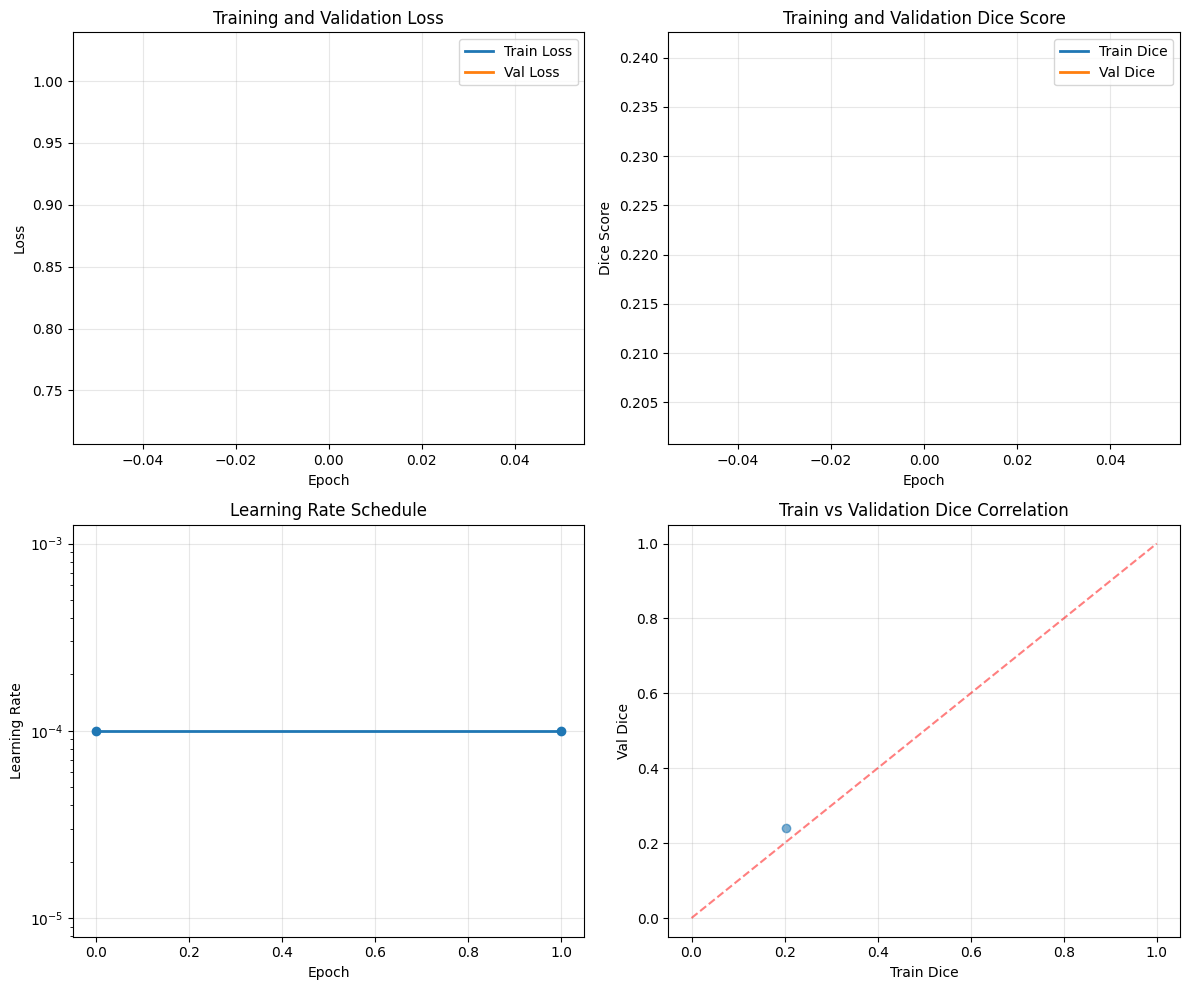

2026-01-09 06:53:23,295 - INFO - 
2026-01-09 06:53:23,312 - INFO - EVALUATION ON TEST SET
2026-01-09 06:53:23,312 - INFO - ============================================================
2026-01-09 07:20:58,620 - INFO - 
Overall Dice Score: 0.2406 ± 0.0434
2026-01-09 07:20:58,620 - INFO - 
Per-class Dice Scores:
2026-01-09 07:20:58,633 - INFO -   AFS   : 0.9820 ± 0.0055
2026-01-09 07:20:58,633 - INFO -   CZ    : 0.1586 ± 0.1830
2026-01-09 07:20:58,633 - INFO -   PG    : 0.4843 ± 0.1098
2026-01-09 07:20:58,633 - INFO -   PZ    : 0.0000 ± 0.0000
2026-01-09 07:20:58,633 - INFO -   SV_L  : 0.0000 ± 0.0000
2026-01-09 07:20:58,633 - INFO -   SV_R  : 0.0002 ± 0.0010
2026-01-09 07:20:58,633 - INFO -   TZ    : 0.0015 ± 0.0034
2026-01-09 07:20:58,633 - INFO - 
Generating prediction visualizations...
C:\Users\Dell\AppData\Local\Temp\ipykernel_6156\3087449651.py:424: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


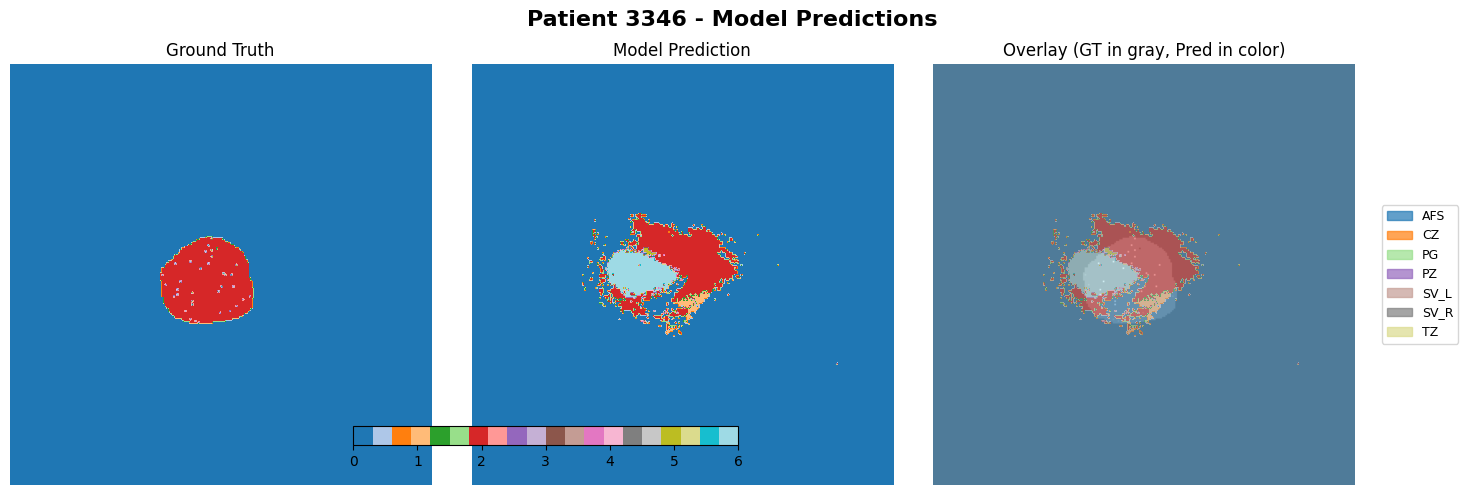

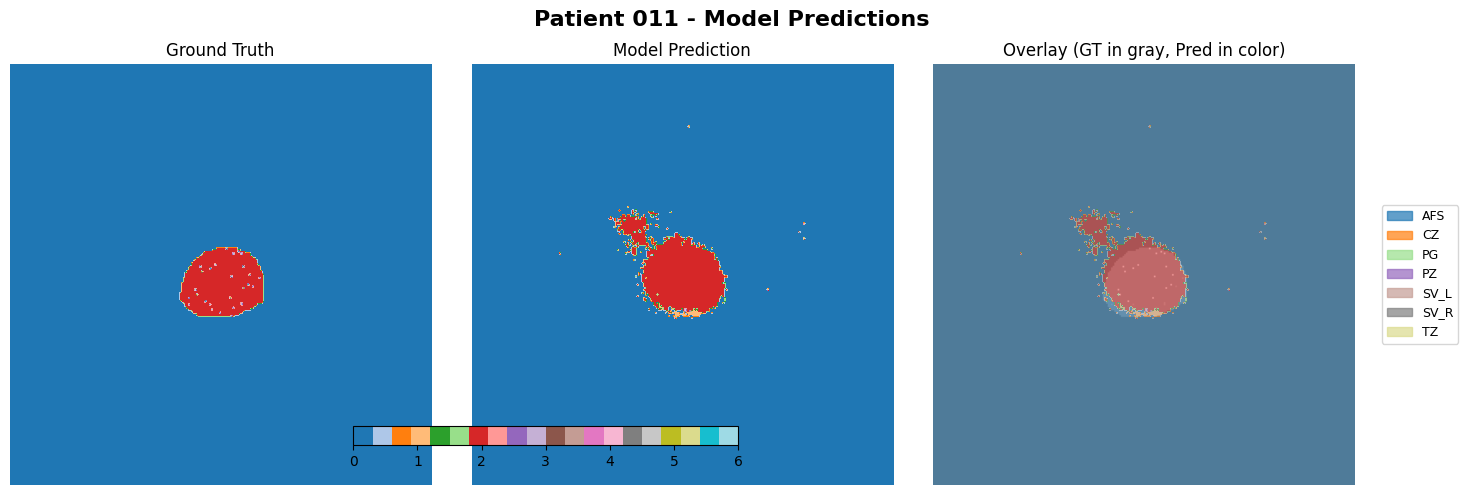

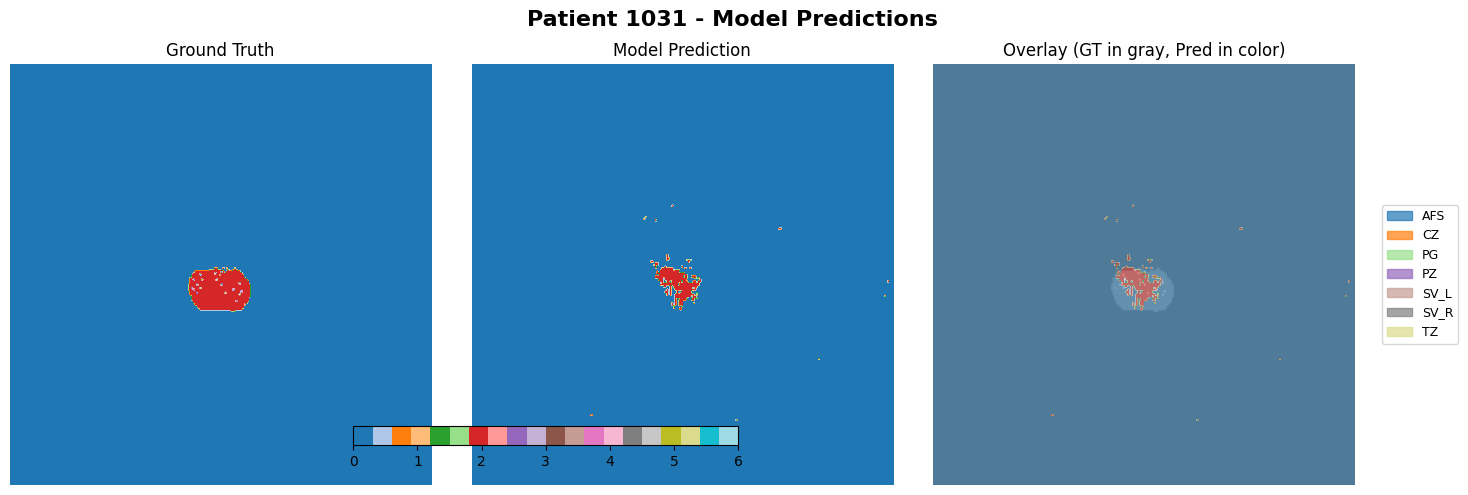

2026-01-09 07:21:00,935 - INFO - 
Training completed successfully!
2026-01-09 07:21:00,935 - INFO - Best validation Dice: 0.2407
2026-01-09 07:21:00,935 - INFO - Test Dice: 0.2406


In [27]:
run_training()

2026-01-09 09:42:33,839 - INFO - Found 531 patients
2026-01-09 09:42:33,841 - INFO - Train: 339 patients
2026-01-09 09:42:33,841 - INFO - Val: 85 patients
2026-01-09 09:42:33,841 - INFO - Test: 107 patients
2026-01-09 09:42:33,893 - INFO - Loaded 339 patients with 3 modalities each
2026-01-09 09:42:33,893 - INFO - Simulating 3 annotators with variance 0.1
2026-01-09 09:42:33,907 - INFO - Loaded 85 patients with 3 modalities each
2026-01-09 09:42:33,907 - INFO - Simulating 3 annotators with variance 0.1
2026-01-09 09:42:33,927 - INFO - Loaded 107 patients with 3 modalities each
2026-01-09 09:42:33,927 - INFO - Simulating 3 annotators with variance 0.1
2026-01-09 09:42:33,929 - INFO - 
Testing data loading...
2026-01-09 09:43:21,563 - INFO - Batch image shape: torch.Size([4, 3, 256, 256])
2026-01-09 09:43:21,563 - INFO - Batch labels shape: torch.Size([4, 7, 256, 256])
2026-01-09 09:43:21,853 - INFO - Initialized trainer on device: cpu
2026-01-09 09:43:21,855 - INFO - Model parameters: 1

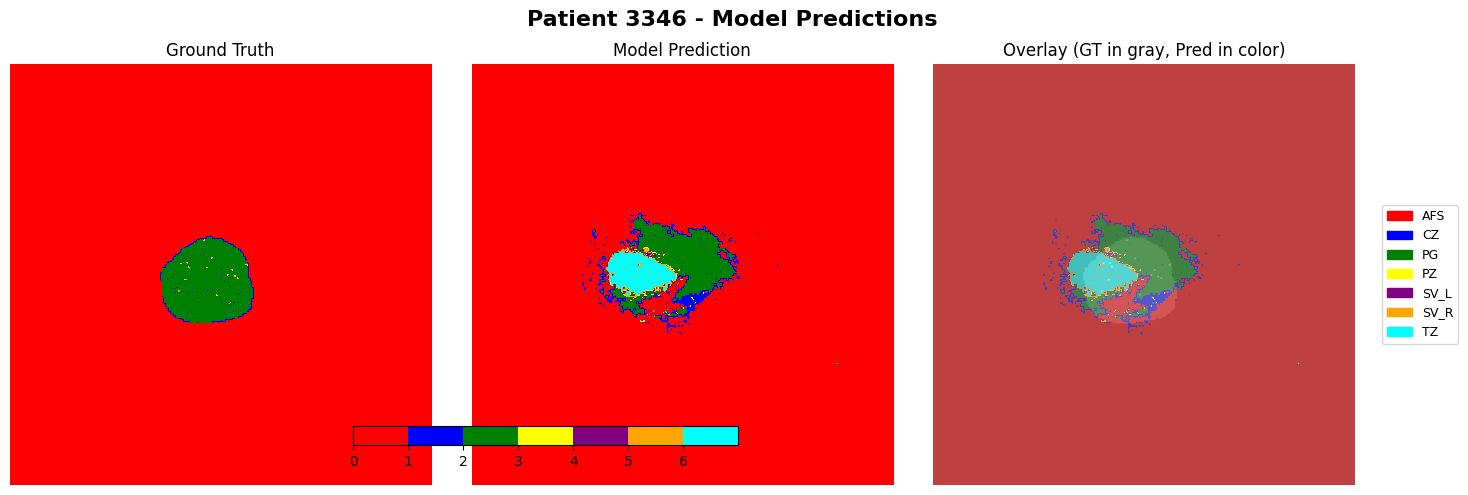

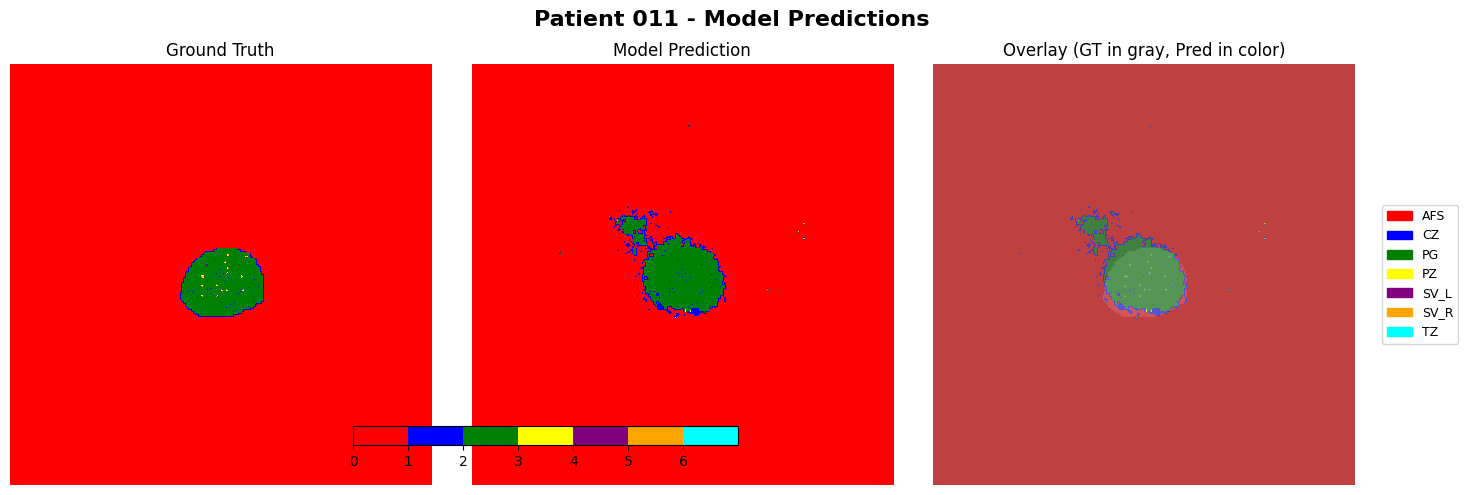

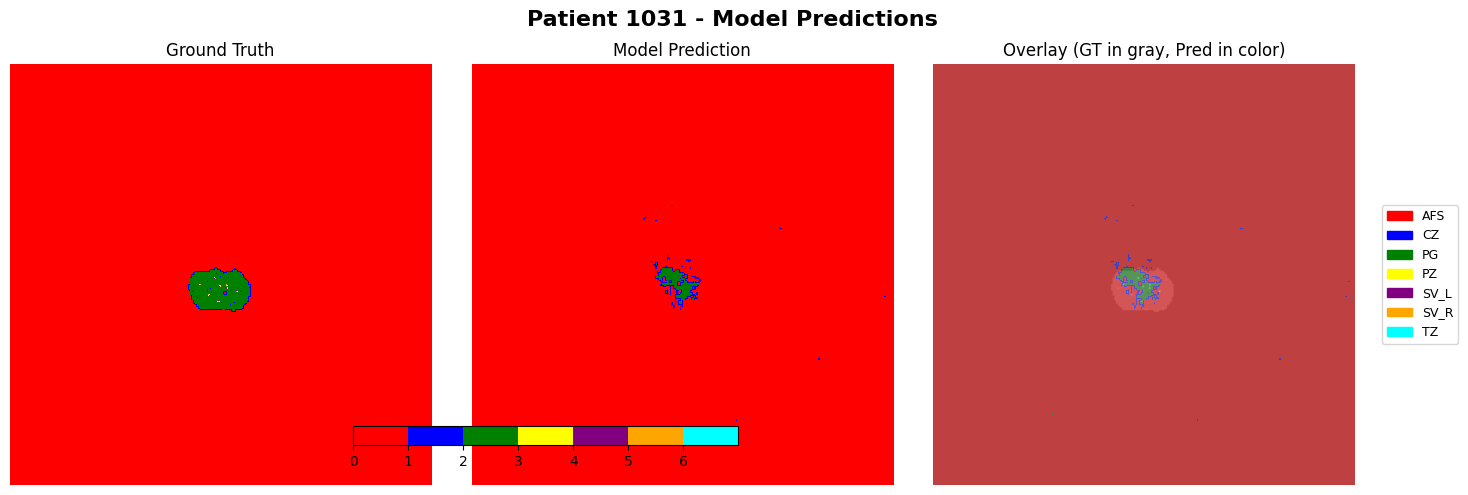

2026-01-09 10:09:43,626 - INFO - 
Training completed successfully!
2026-01-09 10:09:43,626 - INFO - Best validation Dice: 0.0000
2026-01-09 10:09:43,626 - INFO - Test Dice: 0.2407


In [33]:
DATA_ROOT = r"D:\ai4ar\raw\rjozwiak-AI4AR_I_cont\AI4AR_I_cont\AI4AR_cont\Data"
LABELS_ROOT = r"D:\ai4ar\raw\rjozwiak-AI4AR_I_cont\AI4AR_I_cont\AI4AR_cont\Anatomical_Labels"

# # Check paths
# if not os.path.exists(DATA_ROOT) or not os.path.exists(LABELS_ROOT):
#     logger.error("Data paths not found! Please check the paths.")
#     return

# Get patient IDs
patient_ids = [d for d in os.listdir(DATA_ROOT) 
                if os.path.isdir(os.path.join(DATA_ROOT, d))]

# Sort numerically
patient_ids = sorted(patient_ids, key=lambda x: int(x))
logger.info(f"Found {len(patient_ids)} patients")

# Split data
train_ids, test_ids = train_test_split(patient_ids, test_size=0.2, random_state=42)
train_ids, val_ids = train_test_split(train_ids, test_size=0.2, random_state=42)

logger.info(f"Train: {len(train_ids)} patients")
logger.info(f"Val: {len(val_ids)} patients")
logger.info(f"Test: {len(test_ids)} patients")

# Create multi-annotator datasets
train_dataset = MultiAnnotatorProstateDataset(
    data_root=DATA_ROOT,
    labels_root=LABELS_ROOT,
    patient_ids=train_ids,
    modalities=['cor', 'sag', 't2w'],
    target_size=(256, 256),
    normalize=True,
    num_annotators=3,
    annotator_variance=0.1
)

val_dataset = MultiAnnotatorProstateDataset(
    data_root=DATA_ROOT,
    labels_root=LABELS_ROOT,
    patient_ids=val_ids,
    modalities=['cor', 'sag', 't2w'],
    target_size=(256, 256),
    normalize=True,
    num_annotators=3,
    annotator_variance=0.1
)

test_dataset = MultiAnnotatorProstateDataset(
    data_root=DATA_ROOT,
    labels_root=LABELS_ROOT,
    patient_ids=test_ids,
    modalities=['cor', 'sag', 't2w'],
    target_size=(256, 256),
    normalize=True,
    num_annotators=3,
    annotator_variance=0.1
)

# Apply multi-annotator fusion
fusion_method = MultiAnnotatorFusion(num_classes=7)

train_fused_dataset = MultiAnnotatorUNetDataset(
    base_dataset=train_dataset,
    fusion_method=fusion_method,
    use_probabilistic_labels=True
)

val_fused_dataset = MultiAnnotatorUNetDataset(
    base_dataset=val_dataset,
    fusion_method=fusion_method,
    use_probabilistic_labels=False  # Use hard labels for validation
)

test_fused_dataset = MultiAnnotatorUNetDataset(
    base_dataset=test_dataset,
    fusion_method=fusion_method,
    use_probabilistic_labels=False  # Use hard labels for testing
)

# Create dataloaders
train_loader = DataLoader(
    train_fused_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,  # Set to 0 if you have issues with multiprocessing
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_fused_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_fused_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

# Test data loading
logger.info("\nTesting data loading...")
test_batch = next(iter(train_loader))
logger.info(f"Batch image shape: {test_batch['image'].shape}")
logger.info(f"Batch labels shape: {test_batch['labels'].shape}")

# Create model
model = UNet(n_channels=3, n_classes=7, bilinear=True)
checkpoint = torch.load(
    'final_model.pth',
    map_location='cpu',
    weights_only=False
)
model.load_state_dict(checkpoint['model_state_dict'])

# Create trainer
trainer = ProstateSegmentationTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    learning_rate=1e-4,
    weight_decay=1e-5
)

# Train model
# trainer.train(num_epochs=1, patience=10)  # Reduced epochs for testing

# Plot training history
# trainer.plot_training_history()

# Evaluate on test set
logger.info("\n" + "="*60)
logger.info("EVALUATION ON TEST SET")
logger.info("="*60)

avg_results, detailed_results = trainer.evaluate()

logger.info(f"\nOverall Dice Score: {avg_results['mean_dice']:.4f} ± {avg_results['std_dice']:.4f}")
logger.info("\nPer-class Dice Scores:")

label_names = ['AFS', 'CZ', 'PG', 'PZ', 'SV_L', 'SV_R', 'TZ']
for class_idx in range(7):
    mean_dice = avg_results['per_class_mean_dice'][class_idx]
    std_dice = avg_results['per_class_std_dice'][class_idx]
    logger.info(f"  {label_names[class_idx]:6s}: {mean_dice:.4f} ± {std_dice:.4f}")

# Visualize predictions
logger.info("\nGenerating prediction visualizations...")
trainer.visualize_predictions(detailed_results, num_samples=min(3, len(test_ids)))

# Save final model
torch.save({
    'model_state_dict': trainer.model.state_dict(),
    'model_config': {
        'n_channels': 3,
        'n_classes': 7,
        'bilinear': True
    },
    'metrics': avg_results
}, 'final_model.pth')

logger.info("\nTraining completed successfully!")
logger.info(f"Best validation Dice: {trainer.best_val_dice:.4f}")
logger.info(f"Test Dice: {avg_results['mean_dice']:.4f}")